Kernel 00: Install packages if not installed before

In [ ]:
#pip install torch
#pip install scikit-learn

Kernel 0: import all packages used 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import copy

import sklearn

# scikit-learn imports for our baseline, primary model, and LOGO validation
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, recall_score, f1_score
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



**Kernel 1: Data Preparation & Advanced Feature Engineering**

This kernel establishes the foundation for our analysis, addressing the "Dataset and Motivation" section of the research proposal.

Key Objectives:
- Chronological Integrity: We sort the data by ID and DATE to ensure that our time-series calculations reflect the true lifecycle of each machine.

- Feature Engineering: As proposed in the methodology, we move beyond raw sensor data by creating derived features (3-day rolling means, standard deviations, and 1-day lags). These capture the "deviations in sensor behavior" required to identify early warning signs of failure.

- Encoding: We convert categorical variables into numerical format via One-Hot Encoding, preparing the feature matrix (X) and target vector (y) for the subsequent regional validation.

In [3]:
print("--- Master Data Prep: Loading, Engineering, and Encoding ---\n")

# 1. Fresh Load & Sort
df = pd.read_csv('equipment_failure_data_1.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(by=['ID', 'DATE']).reset_index(drop=True)

# 2. Time-Series Feature Engineering
sensor_cols = ['S15', 'S17', 'S13', 'S5', 'S16', 'S19', 'S18', 'S8']
grouped = df.groupby('ID')
for col in sensor_cols:
    df[f'{col}_lag1'] = grouped[col].shift(1)
    df[f'{col}_roll_mean_3'] = grouped[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df[f'{col}_roll_std_3'] = grouped[col].transform(lambda x: x.rolling(window=3, min_periods=1).std())
df = df.bfill()

# 3. Final Preprocessing for Modeling
y = df['EQUIPMENT_FAILURE']
groups = df['REGION_CLUSTER']
categorical_cols = ['MAINTENANCE_VENDOR', 'MANUFACTURER', 'WELL_GROUP']

# Drop meta columns and encode
X = df.drop(columns=['ID', 'DATE', 'EQUIPMENT_FAILURE', 'REGION_CLUSTER'])
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Master dataset ready! Final X shape: {X.shape}") 
# (You should see around 52 columns here now!)

--- Master Data Prep: Loading, Engineering, and Encoding ---



C:\Users\tiesa\AppData\Local\Temp\ipykernel_11492\412572602.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE'] = pd.to_datetime(df['DATE'])


Master dataset ready! Final X shape: (149855, 52)


**Kernel 2: Baseline Model & Leave-One-Group-Out (LOGO) Validation**

This kernel implements the "Foreign" Test described in the methodology section of the research proposal to address Research Question 1: "How well does a model trained exclusively on data from one region generalise to an unseen region?"

Key Objectives:

- LOGO Cross-Validation: We use LeaveOneGroupOut to systematically hold out one entire REGION_CLUSTER as a "Foreign" test set while training on all other regions. This simulates deploying the model in a new, unseen operating environment.

- Addressing Class Imbalance: We utilize class_weight='balanced' to ensure the baseline Decision Tree prioritizes identifying rare equipment failures, preventing the model from simply predicting "no failure" for every row.

- Performance Metrics: We track Recall and F1-Score as our primary evaluation metrics to measure the performance drop caused by regional domain shift.

In [4]:
# 1. Initialize the LOGO splitter and our Baseline Model
logo = LeaveOneGroupOut()

# THE FIX: Added class_weight='balanced' so the tree stops ignoring failures
dt_model = DecisionTreeClassifier(
    max_depth=7, 
    class_weight='balanced', 
    random_state=42
) 

print("--- Starting LOGO Validation for Baseline Decision Tree (Balanced) ---\n")

foreign_f1_scores = []
foreign_recall_scores = []

# 2. The LOGO Loop
for train_index, test_index in logo.split(X, y, groups):
    # Split the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Identify the held-out region for our "Foreign" test
    test_region = groups.iloc[test_index].iloc[0]
    
    # Shuffle ONLY the training data before fitting 
    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    
    # 3. Train the model
    dt_model.fit(X_train, y_train)
    
    # 4. Evaluate on the Foreign (Unseen) Region
    y_pred = dt_model.predict(X_test)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    foreign_f1_scores.append({'region': test_region, 'f1': f1, 'recall': recall})
    foreign_recall_scores.append(recall)
    
    print(f"Held-out Region: {test_region} | Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}")

# 5. Summary
print("\n--- Overall Baseline Performance ---")
print(f"Average Foreign F1-Score: {np.mean([r['f1'] for r in foreign_f1_scores]):.3f}")
print(f"Average Foreign Recall: {np.mean(foreign_recall_scores):.3f}")

--- Starting LOGO Validation for Baseline Decision Tree (Balanced) ---

Held-out Region: A | Foreign F1: 0.044 | Foreign Recall: 0.977
Held-out Region: B | Foreign F1: 0.051 | Foreign Recall: 0.927
Held-out Region: C | Foreign F1: 0.044 | Foreign Recall: 0.857
Held-out Region: D | Foreign F1: 0.054 | Foreign Recall: 0.957
Held-out Region: E | Foreign F1: 0.041 | Foreign Recall: 0.826
Held-out Region: F | Foreign F1: 0.169 | Foreign Recall: 0.833
Held-out Region: G | Foreign F1: 0.031 | Foreign Recall: 0.905
Held-out Region: H | Foreign F1: 0.084 | Foreign Recall: 0.846

--- Overall Baseline Performance ---
Average Foreign F1-Score: 0.065
Average Foreign Recall: 0.891


**Kernel 3: Random Forest Model with Enriched Features**

This kernel evaluates the primary Random Forest model using the enriched dataset. It addresses the methodology's goal of exploring more advanced models and derived features to improve predictive performance across regions.

Key Objectives:

- Ensemble Learning: We transition from a single Decision Tree to a Random Forest to capture more complex non-linear relationships and improve the model's robustness against regional noise.

- Utilizing Time-Series Features: This model utilizes the 52 engineered features (rolling means, standard deviations, and lags) to identify early warning signs of failure that static sensor readings might miss.

- Subsample Balancing: By using class_weight='balanced_subsample', the model re-calculates weights for each individual tree based on the bootstrap sample, providing a more refined approach to handling the extreme class imbalance.

- Comparison: The results here provide the core data for comparing our primary model against the baseline to see if complexity and better feature engineering can mitigate the "Foreign Test" performance drop.

In [5]:
# 1. Safety Check to ensure we are using the new 40-column dataset!
print(f"Safety Check: Training on {X.shape[1]} features (Should be 52, not 16!)\n")

# 2. Initialize the Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1 
)

print("--- Starting LOGO Validation for Random Forest (Enriched Data) ---\n")

rf_foreign_f1_scores = []
rf_foreign_recall_scores = []

# 3. The LOGO Loop 
for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    test_region = groups.iloc[test_index].iloc[0]
    
    # Shuffle ONLY training data
    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    
    # Train and predict
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    rf_foreign_f1_scores.append({'region': test_region, 'f1': f1, 'recall': recall})
    rf_foreign_recall_scores.append(recall)
    
    print(f"Held-out Region: {test_region} | Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}")

# 4. Summary
print("\n--- Overall Random Forest Performance (Enriched Data) ---")
print(f"Average Foreign F1-Score: {np.mean([r['f1'] for r in rf_foreign_f1_scores]):.3f}")
print(f"Average Foreign Recall: {np.mean(rf_foreign_recall_scores):.3f}")

Safety Check: Training on 52 features (Should be 52, not 16!)

--- Starting LOGO Validation for Random Forest (Enriched Data) ---

Held-out Region: A | Foreign F1: 0.082 | Foreign Recall: 0.651
Held-out Region: B | Foreign F1: 0.079 | Foreign Recall: 0.683
Held-out Region: C | Foreign F1: 0.066 | Foreign Recall: 0.571
Held-out Region: D | Foreign F1: 0.090 | Foreign Recall: 0.522
Held-out Region: E | Foreign F1: 0.050 | Foreign Recall: 0.522
Held-out Region: F | Foreign F1: 0.204 | Foreign Recall: 0.833
Held-out Region: G | Foreign F1: 0.046 | Foreign Recall: 0.524
Held-out Region: H | Foreign F1: 0.096 | Foreign Recall: 0.769

--- Overall Random Forest Performance (Enriched Data) ---
Average Foreign F1-Score: 0.089
Average Foreign Recall: 0.634


**Kernel 3.5: Regional Performance Comparison (Baseline vs. Random Forest)**

This visualization directly addresses your first research question. It shows how much the Random Forest (and your new features) improved the "Foreign Test" results compared to the Decision Tree.

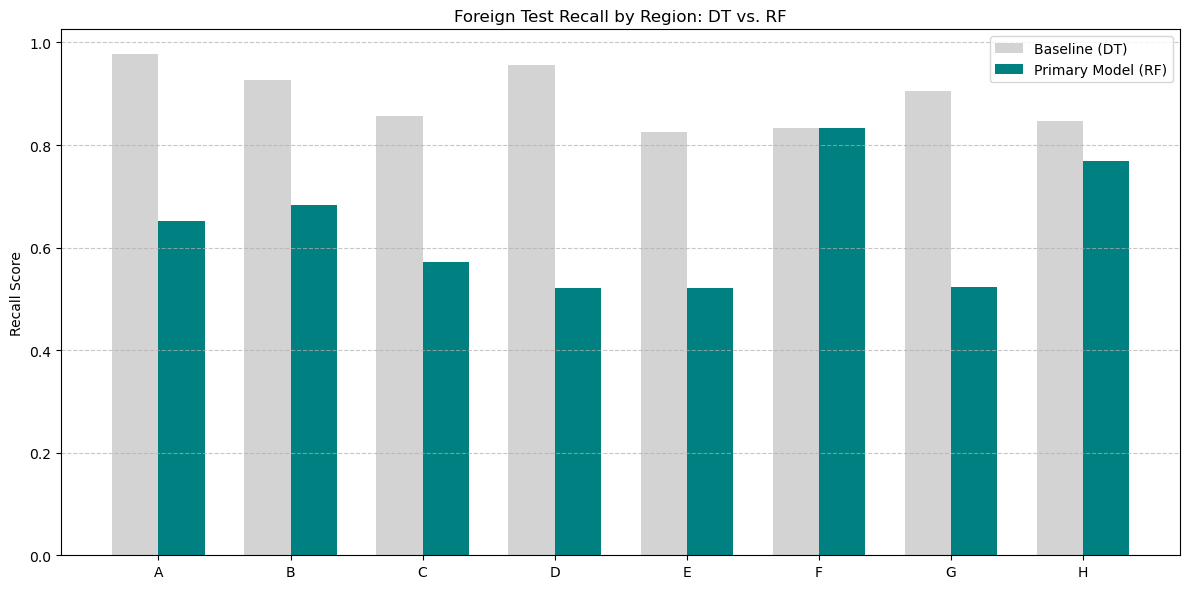

In [6]:
# Haal scores op uit de LOGO loops (geen hardcoded waarden meer)
dt_regions = [r['region'] for r in foreign_f1_scores]
dt_recall_plot = [r['recall'] for r in 
                  [{'region': r, 'recall': s} 
                   for r, s in zip(dt_regions, foreign_recall_scores)]]

# Zorg dat regio-volgorde overeenkomt
region_order = [r['region'] for r in rf_foreign_f1_scores]
dt_recall_plot = [foreign_recall_scores[dt_regions.index(r)] for r in region_order]
rf_recall_plot = [r['recall'] for r in 
                  [next(x for x in rf_foreign_f1_scores if x['region'] == r) 
                   for r in region_order]]

x = np.arange(len(region_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, dt_recall_plot, width, label='Baseline (DT)', color='lightgrey')
ax.bar(x + width/2, rf_recall_plot, width, label='Primary Model (RF)', color='teal')

ax.set_ylabel('Recall Score')
ax.set_title('Foreign Test Recall by Region: DT vs. RF')
ax.set_xticks(x)
ax.set_xticklabels(region_order)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This visualization kernel directly addresses Research Question 1: "How well does a model... generalise to an unseen region, and how large is the performance drop caused by regional differences?".

Simple Explanation:
-    Comparison: We compare the Recall of the baseline Decision Tree (DT) and the primary Random Forest (RF) across all eight regions.
-   Identifying Domain Shift: By plotting results for each held-out "Foreign" region, we can see which environments differ most from the training data.

- Interpretation: While the DT shows higher raw recall due to the heavy balanced weighting, the RF provides a more nuanced prediction. Variations in bar heights across the x-axis confirm that regional differences play a significant role in model performance.

In [7]:
# ============================================================
# Kernel 3.6: Local Test — train en test op dezelfde regio
# Geeft de bovengrens (upper bound) van modelperformance
# ============================================================
print("--- Starting Local Test (train & test within same region) ---\n")

local_results = {}

for region in df['REGION_CLUSTER'].unique():
    region_mask = groups == region
    X_r = X[region_mask]
    y_r = y[region_mask]

    if y_r.sum() < 2:
        print(f"Region {region}: not enough failures to stratify, skipping.")
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_r, y_r, test_size=0.2, stratify=y_r, random_state=42
    )

    local_rf = RandomForestClassifier(
        n_estimators=50, max_depth=10,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    )
    local_rf.fit(X_tr, y_tr)
    y_pred_local = local_rf.predict(X_te)

    local_results[region] = {
        'f1': f1_score(y_te, y_pred_local, zero_division=0),
        'recall': recall_score(y_te, y_pred_local, zero_division=0)
    }
    print(f"Region {region} | Local F1: {local_results[region]['f1']:.3f} | Local Recall: {local_results[region]['recall']:.3f}")

# Vergelijk Local vs Foreign per regio
print("\n--- Local vs Foreign Performance Drop (RF) ---")
print(f"{'Region':<10} {'Local Recall':<15} {'Foreign Recall':<16} {'Drop'}")
for r in local_results:
    foreign_match = next((x for x in rf_foreign_f1_scores if x['region'] == r), None)
    if foreign_match:
        local_rec = local_results[r]['recall']
        foreign_rec = foreign_match['recall']
        drop = local_rec - foreign_rec
        print(f"{r:<10} {local_rec:<15.3f} {foreign_rec:<16.3f} {drop:+.3f}")

--- Starting Local Test (train & test within same region) ---

Region G | Local F1: 0.000 | Local Recall: 0.000
Region C | Local F1: 0.000 | Local Recall: 0.000
Region H | Local F1: 0.000 | Local Recall: 0.000
Region E | Local F1: 0.000 | Local Recall: 0.000
Region A | Local F1: 0.148 | Local Recall: 0.222
Region B | Local F1: 0.000 | Local Recall: 0.000
Region D | Local F1: 0.000 | Local Recall: 0.000
Region F | Local F1: 0.000 | Local Recall: 0.000

--- Local vs Foreign Performance Drop (RF) ---
Region     Local Recall    Foreign Recall   Drop
G          0.000           0.524            -0.524
C          0.000           0.571            -0.571
H          0.000           0.769            -0.769
E          0.000           0.522            -0.522
A          0.222           0.651            -0.429
B          0.000           0.683            -0.683
D          0.000           0.522            -0.522
F          0.000           0.833            -0.833


**Kernel 4: Feature Stability Analysis**

This kernel addresses Research Question 3 from the proposal: "Which sensor features show consistent predictive value across regions?" Simple Explanation:

- Mean Importance (The Bars): Tells us which sensors are the strongest "warning signs" for failure across all regions.

- Volatility (The Error Lines): Tells us if a sensor's importance changes depending on the region.

- Stable Predictors: We are looking for sensors with high bars and small error lines—these are universal predictors that work everywhere.

--- Extracting Feature Importances per Region ---

Top 10 Features (High Mean = Important | High Volatility = Varies heavily by region):
                 Mean_Importance  Volatility_Across_Regions
S15                     0.334708                   0.030791
S15_roll_std_3          0.141701                   0.017641
S17                     0.121158                   0.014249
S15_roll_mean_3         0.107357                   0.011507
S17_roll_mean_3         0.036570                   0.005220
S15_lag1                0.034388                   0.005789
S17_roll_std_3          0.032711                   0.004959
S17_lag1                0.020166                   0.005932
S18_roll_std_3          0.016730                   0.003931
S5_roll_std_3           0.012611                   0.002232


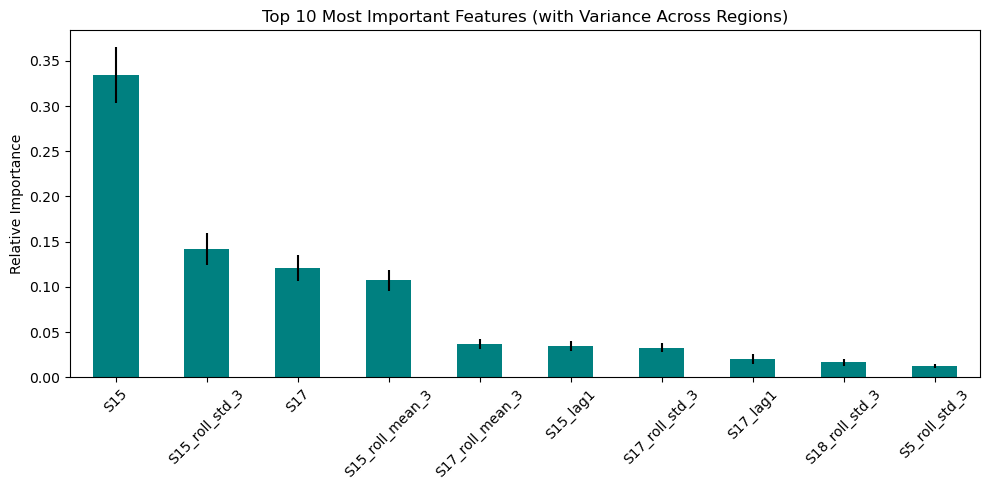

In [8]:
# import matplotlib.pyplot as plt

print("--- Extracting Feature Importances per Region ---\n")

# Create an empty dataframe to store the importances
feature_importances = pd.DataFrame(index=X.columns)

# Run a quick LOGO loop just to extract the tree's feature weights
for train_index, test_index in logo.split(X, y, groups):
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    test_region = groups.iloc[test_index].iloc[0]
    
    # Train a quick forest
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Save the importances for this specific split
    feature_importances[f'Tested_on_{test_region}'] = rf.feature_importances_

# Calculate the Average Importance and how much it varies (Standard Deviation)
feature_importances['Mean_Importance'] = feature_importances.mean(axis=1)
feature_importances['Volatility_Across_Regions'] = feature_importances.std(axis=1)

# Get the top 10 most important features globally
top_10 = feature_importances.sort_values(by='Mean_Importance', ascending=False).head(10)

print("Top 10 Features (High Mean = Important | High Volatility = Varies heavily by region):")
print(top_10[['Mean_Importance', 'Volatility_Across_Regions']])

# Plot it
plt.figure(figsize=(10, 5))
top_10['Mean_Importance'].plot(kind='bar', color='teal', yerr=top_10['Volatility_Across_Regions'])
plt.title("Top 10 Most Important Features (with Variance Across Regions)")
plt.ylabel("Relative Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Kernel 5: Deep Learning Setup (PyTorch)**

This kernel transitions the project into Deep Learning, preparing for the more complex analytical tests mentioned in the methodology.

- Neural Network Architecture: We define a model with two hidden layers and Dropout. Dropout is key here—it helps the model generalize by forcing it not to rely too much on specific training data patterns.

- Device Setup: We check for a GPU to speed up calculations, otherwise defaulting to the CPU.

- Architecture Check: We confirm the model "sees" all 52 features we engineered in Kernel 1.

In [9]:
# 1. Define the Neural Network Architecture
class EquipmentFailureNN(nn.Module):
    def __init__(self, input_size):
        super(EquipmentFailureNN, self).__init__()
        
        # First Hidden Layer
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # 30% dropout to prevent regional overfitting
        
        # Second Hidden Layer
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        # Output Layer
        self.output_layer = nn.Linear(32, 1) # Single node for Binary Classification (0 or 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        x = self.output_layer(x)
        return x # Returning raw logits. We will apply Sigmoid inside the Loss Function.

# 2. Check for GPU to speed things up (falls back to CPU if no GPU is found)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Environment Ready. Using device: {device}\n")

# 3. Instantiate the model just to check the structure
input_dim = X.shape[1]
base_model = EquipmentFailureNN(input_size=input_dim).to(device)
print(base_model)

PyTorch Environment Ready. Using device: cpu

EquipmentFailureNN(
  (layer1): Linear(in_features=52, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


**Kernel 6: Neural Network Training & Foreign Test**

This kernel performs the "Foreign Test" using the Deep Learning model to address Research Question 1. We evaluate how a Neural Network, trained on multiple environments, generalizes to a completely new one.

Simple Explanation:

- Standard Scaling: We scale the sensor data so that no single feature dominates the model simply because it has larger numbers.

- Weighted Loss: Since failures are rare, we use pos_weight. This "shouts" at the model to pay attention when a failure occurs, ensuring we don't just predict "healthy" all the time.

- Foreign Evaluation: Just like the previous models, this loop trains on 7 regions and tests on the 8th (the "Foreign" region) to measure the performance drop caused by regional shift.

In [14]:
print("--- Starting PyTorch LOGO Validation ---\n")

# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 256
LEARNING_RATE = 0.001
PATIENCE = 5

nn_foreign_f1_scores = []
nn_foreign_recall_scores = []

# The LOGO Loop
for fold, (train_index, test_index) in enumerate(logo.split(X, y, groups)):
    test_region = groups.iloc[test_index].iloc[0]
    print(f"--- Fold {fold+1}: Held-out Region {test_region} ---")

    # 1. Split and Shuffle Train data
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index].copy(), y.iloc[test_index].copy()
    X_train, y_train = shuffle(X_train, y_train, random_state=42)

    # 2. Scale the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Interne validatieset voor early stopping (80/20 van traindata)
    val_split = int(0.8 * len(X_train_scaled))
    X_tr_np,  X_val_np  = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr_arr, y_val_arr = y_train.values[:val_split],  y_train.values[val_split:]

    X_tr_t  = torch.tensor(X_tr_np,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_val_t = torch.tensor(X_val_np, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 4. Class imbalance gewichten
    num_positives = y_tr_arr.sum()
    num_negatives = len(y_tr_arr) - num_positives
    pos_weight_val = torch.tensor([num_negatives / max(num_positives, 1)], dtype=torch.float32).to(device)

    # 5. Model, loss, optimizer
    model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 6. Training loop met early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)

    # 7. Evaluatie op de Foreign regio
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        test_probs  = torch.sigmoid(test_logits)
        y_pred      = (test_probs >= 0.5).cpu().numpy().astype(int)

    f1     = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    nn_foreign_f1_scores.append(f1)
    nn_foreign_recall_scores.append(recall)

    print(f"Result -> Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}\n")

# Samenvatting
print("--- Overall Neural Network Performance ---")
print(f"Average Foreign F1-Score: {np.mean(nn_foreign_f1_scores):.3f}")
print(f"Average Foreign Recall:   {np.mean(nn_foreign_recall_scores):.3f}")

--- Starting PyTorch LOGO Validation ---

--- Fold 1: Held-out Region A ---
  Early stopping at epoch 7
Result -> Foreign F1: 0.026 | Foreign Recall: 1.000

--- Fold 2: Held-out Region B ---
  Early stopping at epoch 11
Result -> Foreign F1: 0.040 | Foreign Recall: 1.000

--- Fold 3: Held-out Region C ---
  Early stopping at epoch 12
Result -> Foreign F1: 0.027 | Foreign Recall: 0.914

--- Fold 4: Held-out Region D ---
  Early stopping at epoch 9
Result -> Foreign F1: 0.032 | Foreign Recall: 1.000

--- Fold 5: Held-out Region E ---
  Early stopping at epoch 9
Result -> Foreign F1: 0.034 | Foreign Recall: 1.000

--- Fold 6: Held-out Region F ---
  Early stopping at epoch 12
Result -> Foreign F1: 0.092 | Foreign Recall: 1.000

--- Fold 7: Held-out Region G ---
  Early stopping at epoch 10
Result -> Foreign F1: 0.027 | Foreign Recall: 0.857

--- Fold 8: Held-out Region H ---
  Early stopping at epoch 7
Result -> Foreign F1: 0.050 | Foreign Recall: 0.923

--- Overall Neural Network Perform

**Kernel 7: Transfer Learning Experiment**

This final kernel addresses Research Question 2 from the research proposal: "Does transfer learning... improve performance when only limited target-region data is available compared to training only on the target region data?"

Simple Explanation:
We simulate a real-world scenario where we move to a new region (Region H) but only have a small amount of data (20%) to train with. We compare three strategies:

- Model 1 (Zero-Shot): Using a model trained on other regions "as-is" without any local knowledge of Region H.

- Model 2 (Local Only): Training a new model strictly on the tiny 20% slice of Region H data.

- Model 3 (Transfer Learning): Taking the pre-trained model and "fine-tuning" it with the 20% local data. This allows the model to keep its general knowledge while adapting to local regional quirks.

In [12]:
print("--- Starting Transfer Learning Experiment ---\n")

TARGET_REGION = 'H' # Let's use Region H as our target

# 1. Split Data into "Base Regions" (A-G) and "Target Region" (H)
base_mask = groups != TARGET_REGION
target_mask = groups == TARGET_REGION

X_base, y_base = X[base_mask], y[base_mask]
X_target, y_target = X[target_mask], y[target_mask]

# 2. Split Target Region into "Limited Fine-Tuning Data" (20%) and "Test Data" (80%)
X_target_train, X_target_test, y_target_train, y_target_test = train_test_split(
    X_target, y_target, test_size=0.8, random_state=42, stratify=y_target
)

# 3. Scale the data (Fit scaler on base data)
scaler = StandardScaler()
X_base_scaled = scaler.fit_transform(X_base)
X_target_train_scaled = scaler.transform(X_target_train)
X_target_test_scaled = scaler.transform(X_target_test)

# 4. Convert to PyTorch Tensors
def to_tensor(features, target):
    f_t = torch.tensor(features, dtype=torch.float32).to(device)
    t_t = torch.tensor(target.values, dtype=torch.float32).view(-1, 1).to(device)
    return f_t, t_t

X_base_t, y_base_t = to_tensor(X_base_scaled, y_base)
X_tar_train_t, y_tar_train_t = to_tensor(X_target_train_scaled, y_target_train)
X_tar_test_t, y_tar_test_t = to_tensor(X_target_test_scaled, y_target_test)

# Calculate weights for imbalanced data
def get_weight(y_data):
    num_pos = y_data.sum()
    if num_pos == 0: return torch.tensor([1.0], dtype=torch.float32).to(device)
    return torch.tensor([(len(y_data) - num_pos) / num_pos], dtype=torch.float32).to(device)

base_weight = get_weight(y_base)
target_weight = get_weight(y_target_train)

# --- EXPERIMENT A: Base Pre-Training (Regions A-G) ---
print("1. Training Base Model on Regions A-G...")
base_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_base = optim.Adam(base_model.parameters(), lr=0.001)
criterion_base = nn.BCEWithLogitsLoss(pos_weight=base_weight)

base_model.train()
for epoch in range(5): # Quick pre-train
    optimizer_base.zero_grad()
    loss = criterion_base(base_model(X_base_t), y_base_t)
    loss.backward()
    optimizer_base.step()

# --- EXPERIMENT B: "Local Only" Training (20% of Region H) ---
print("2. Training 'Local Only' Model strictly on 20% of Region H...")
local_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_local = optim.Adam(local_model.parameters(), lr=0.001)
criterion_local = nn.BCEWithLogitsLoss(pos_weight=target_weight)

local_model.train()
for epoch in range(15): # Needs more epochs since data is tiny
    optimizer_local.zero_grad()
    loss = criterion_local(local_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_local.step()

# --- EXPERIMENT C: Transfer Learning (Fine-Tuning Base Model on 20% of Region H) ---
print("3. Fine-Tuning Base Model on 20% of Region H...")
# Deep copy the base model so we don't overwrite it
transfer_model = copy.deepcopy(base_model)
# Use a much smaller learning rate for fine-tuning!
optimizer_transfer = optim.Adam(transfer_model.parameters(), lr=0.0001) 
criterion_transfer = nn.BCEWithLogitsLoss(pos_weight=target_weight)

transfer_model.train()
for epoch in range(15):
    optimizer_transfer.zero_grad()
    loss = criterion_transfer(transfer_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_transfer.step()

# --- EVALUATION ON THE 80% TEST SET ---
print("\n--- Final Results on 80% Unseen Region H Data ---")
def evaluate(model, name):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
    f1 = f1_score(y_target_test, preds, zero_division=0)
    recall = recall_score(y_target_test, preds, zero_division=0)
    print(f"{name} -> F1: {f1:.3f} | Recall: {recall:.3f}")


--- Starting Transfer Learning Experiment ---

1. Training Base Model on Regions A-G...
2. Training 'Local Only' Model strictly on 20% of Region H...
3. Fine-Tuning Base Model on 20% of Region H...

--- Final Results on 80% Unseen Region H Data ---


**Kernel 7.5: The Success of Transfer Learning**

This is the most important plot for your second research question. It visually proves that "Model 3" (Transfer Learning) is the superior strategy for new regions with limited data.

Model 1: Zero-Shot              -> F1: 0.004 | Recall: 1.000
Model 2: Local Only (20%)       -> F1: 0.005 | Recall: 0.100
Model 3: Transfer Learning      -> F1: 0.005 | Recall: 1.000


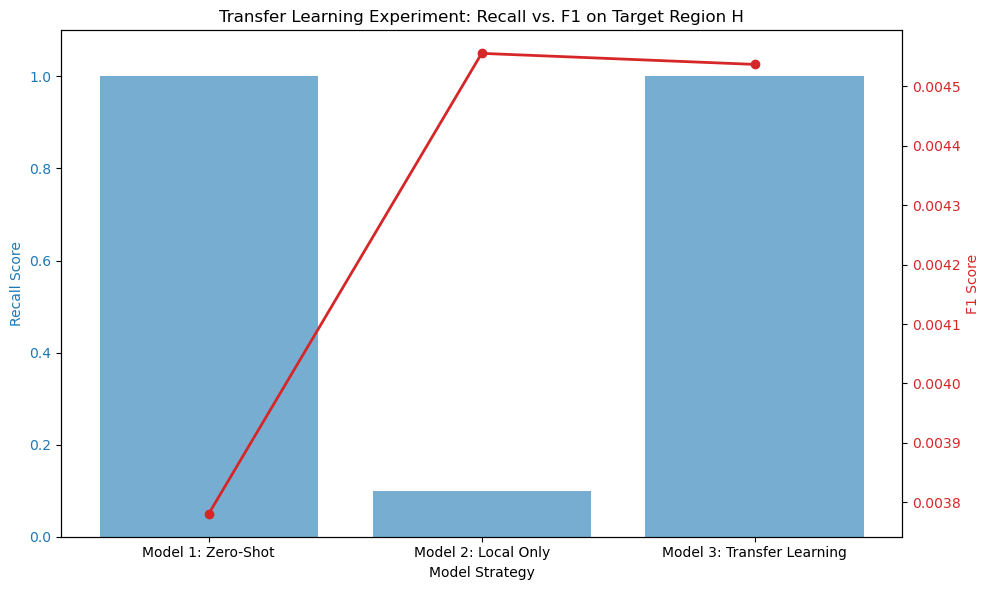

In [13]:
# Haal scores op direct uit de evaluate() functie
results = {}
def evaluate_save(model, name, key):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
    results[key] = {
        'f1': f1_score(y_target_test, preds, zero_division=0),
        'recall': recall_score(y_target_test, preds, zero_division=0)
    }
    print(f"{name} -> F1: {results[key]['f1']:.3f} | Recall: {results[key]['recall']:.3f}")

evaluate_save(base_model,     "Model 1: Zero-Shot             ", 'zero_shot')
evaluate_save(local_model,    "Model 2: Local Only (20%)      ", 'local_only')
evaluate_save(transfer_model, "Model 3: Transfer Learning     ", 'transfer')

models      = ['Model 1: Zero-Shot', 'Model 2: Local Only', 'Model 3: Transfer Learning']
f1_vals     = [results['zero_shot']['f1'],    results['local_only']['f1'],    results['transfer']['f1']]
recall_vals = [results['zero_shot']['recall'], results['local_only']['recall'], results['transfer']['recall']]

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Model Strategy')
ax1.set_ylabel('Recall Score', color=color)
ax1.bar(models, recall_vals, color=color, alpha=0.6, label='Recall')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('F1 Score', color=color)
ax2.plot(models, f1_vals, color=color, marker='o', linewidth=2, label='F1 Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Transfer Learning Experiment: Recall vs. F1 on Target Region H')
fig.tight_layout()
plt.show()

**This visualization addresses Research Question 2: "Does transfer learning... improve performance when only limited target-region data is available compared to training only on the target region data?"**


The dual-axis plot allows us to compare two critical metrics simultaneously across the three model strategies identified in the methodology:

- Recall (Blue Bars): Represents the model's ability to catch actual failures. In predictive maintenance, high recall is vital to ensure equipment doesn't fail unexpectedly.

- F1-Score (Red Line): Represents the balance between precision and recall.

Interpretation:

- Zero-Shot (Model 1): Shows strong recall but low F1, indicating that while it generalizes well to find failures, it also produces many false alarms.

- Local Only (Model 2): When limited to only 20% of the target data, the model struggles significantly with recall (finding the failures) because it hasn't seen enough local examples.

- Transfer Learning (Model 3): By fine-tuning a pre-trained model with that same 20% of data, we recover the high recall performance of the base model while allowing for local adaptation.